In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pydicom
from pathlib import Path
import cv2

In [2]:
train_rle = pd.read_csv('pneumothorax_data/train-rle.csv')
train_dicom_path = Path('pneumothorax_data/dicom-images-train')

In [62]:
print(f"Total images: {len(train_rle)}")
print(f"\nFirst 5 rows:")
train_rle.head()

Total images: 11582

First 5 rows:


,ImageId,EncodedPixels
0,1.2.276.0.7230010.3.1.4.8323329.5597.151787518...,-1
1,1.2.276.0.7230010.3.1.4.8323329.12515.15178752...,-1
2,1.2.276.0.7230010.3.1.4.8323329.4904.151787518...,175349 7 1013 12 1009 17 1005 19 1003 20 1002...
3,1.2.276.0.7230010.3.1.4.8323329.32579.15178751...,407576 2 1021 7 1015 10 1013 12 1011 14 1008 ...
4,1.2.276.0.7230010.3.1.4.8323329.32579.15178751...,252069 1 1021 3 1020 4 1018 5 1018 6 1016 7 1...


In [63]:
unique_images = train_rle['ImageId'].nunique()
total_rows = len(train_rle)
total_rows

11582

### 데이터 분포

Pneumothorax 있음: 3286 (28.37%)
Pneumothorax 없음: 8296 (71.63%)


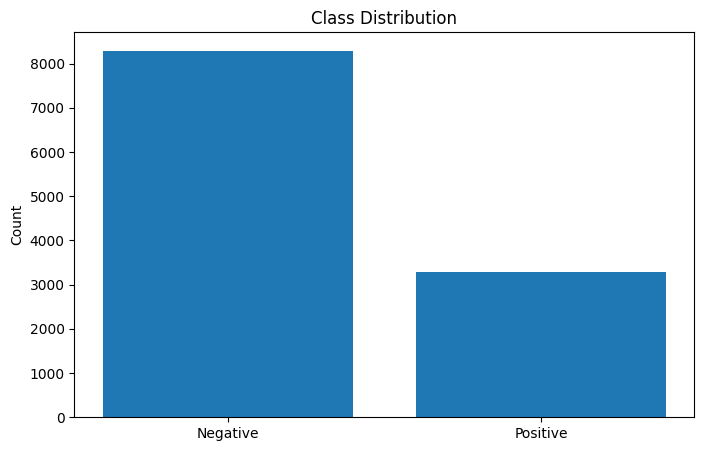

In [64]:
train_rle['has_pneumothorax'] = (train_rle[' EncodedPixels'] != ' -1')

positive = train_rle['has_pneumothorax'].sum()
negative = len(train_rle) - positive

print(f"Pneumothorax 있음: {positive} ({positive/len(train_rle)*100:.2f}%)")
print(f"Pneumothorax 없음: {negative} ({negative/len(train_rle)*100:.2f}%)")

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(['Negative', 'Positive'], [negative, positive])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

### DICOM 이미지 샘플

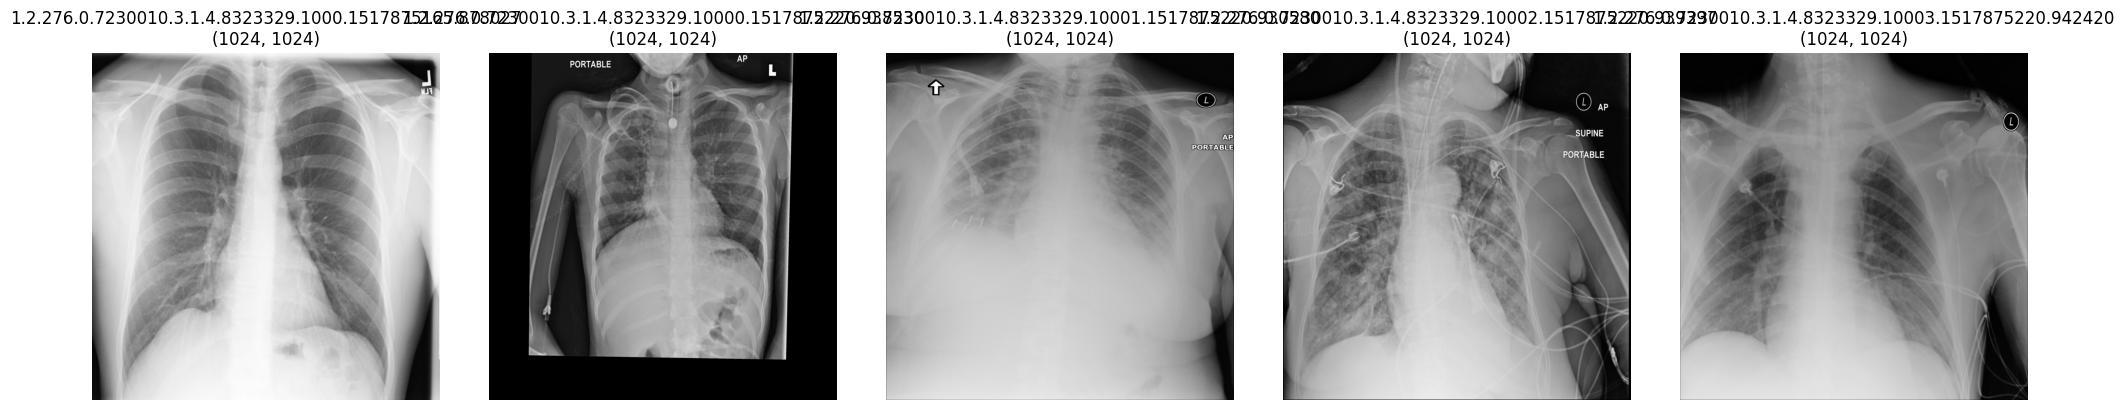

In [65]:
sample_files = list(train_dicom_path.rglob('*.dcm'))[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for idx, file_path in enumerate(sample_files):
    dcm = pydicom.dcmread(file_path)
    img = dcm.pixel_array
    
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f"{file_path.stem}\n{img.shape}")
    axes[idx].axis('off')
plt.tight_layout()
plt.show()

### 이미지 크기
- (1024, 1024)로 크기 통일됨

In [ ]:
# image_shapes = []
# for file_path in list(train_dicom_path.rglob('*.dcm')):
#     dcm = pydicom.dcmread(file_path)
#     image_shapes.append(dcm.pixel_array.shape)

# unique_shapes = pd.Series(image_shapes).value_counts()
# print(unique_shapes)

### RLE 인코딩 확인

In [ ]:
positive_samples = train_rle[train_rle['has_pneumothorax']].head(3)

for idx, row in positive_samples.iterrows():
    print(f"\nImageId: {row['ImageId']}")
    print(f"RLE (first 100 chars): {str(row[' EncodedPixels'])[:100]}...")


ImageId: 1.2.276.0.7230010.3.1.4.8323329.4904.1517875185.355709
RLE (first 100 chars):  175349 7 1013 12 1009 17 1005 19 1003 20 1002 22 1001 22 1000 23 1000 23 1000 23 999 24 999 23 1000...

ImageId: 1.2.276.0.7230010.3.1.4.8323329.32579.1517875161.299312
RLE (first 100 chars):  407576 2 1021 7 1015 10 1013 12 1011 14 1008 17 1006 19 1005 20 1003 21 1003 22 1001 23 1001 24 999...

ImageId: 1.2.276.0.7230010.3.1.4.8323329.32579.1517875161.299312
RLE (first 100 chars):  252069 1 1021 3 1020 4 1018 5 1018 6 1016 7 1015 8 1014 9 1014 9 1013 10 1013 10 1012 11 1011 12 10...


175349 7 1013 12 1009 17 1005 19 ..
- 17539부터 7칸, 1013칸 이동 후에 12칸 .... <- masking 영역

### RLE decoding으로 마스크 시각화

In [ ]:
def rle_decode(rle, width, height):
    if pd.isna(rle) or str(rle).strip() == '-1':
        return np.zeros((height, width), dtype=np.uint8)
    
    array = np.asarray([int(x) for x in str(rle).strip().split()]) #RLE 문자열 -> int 리스트
    starts = array[0::2] #짝수 인덱스값 : mask 픽셀 사이 간격
    lengths = array[1::2] #홀수 인덱스 : mask 길이
    
    current_position = 0
    mask = np.zeros(width * height, dtype=np.uint8)
    
    for start, length in zip(starts, lengths):
        current_position += start
        mask[current_position:current_position+length] = 1
        current_position += length
    
    return mask.reshape(width, height).T

In [ ]:
mask_sizes = []
for idx, row in train_rle[train_rle['has_pneumothorax']].iterrows():
    rle = row[' EncodedPixels']
    s = rle.split()
    lengths = np.asarray(s[1::2], dtype=int)
    total_size = lengths.sum()
    mask_sizes.append({'ImageId': row['ImageId'], 'mask_size': total_size})

mask_df = pd.DataFrame(mask_sizes).sort_values('mask_size', ascending=False)
print("Top 10 largest masks:")
print(mask_df.head(10))

Top 10 largest masks:
                                                ImageId  mask_size
2728  1.2.276.0.7230010.3.1.4.8323329.5498.151787518...     161421
648   1.2.276.0.7230010.3.1.4.8323329.5085.151787518...     145885
2799  1.2.276.0.7230010.3.1.4.8323329.1959.151787517...     134354
1713  1.2.276.0.7230010.3.1.4.8323329.12773.15178752...     126868
2106  1.2.276.0.7230010.3.1.4.8323329.574.1517875163...     117180
2723  1.2.276.0.7230010.3.1.4.8323329.5526.151787518...     107687
3019  1.2.276.0.7230010.3.1.4.8323329.5405.151787518...     104516
2845  1.2.276.0.7230010.3.1.4.8323329.11689.15178752...     102743
128   1.2.276.0.7230010.3.1.4.8323329.11858.15178752...      99119
2406  1.2.276.0.7230010.3.1.4.8323329.2915.151787517...      98093


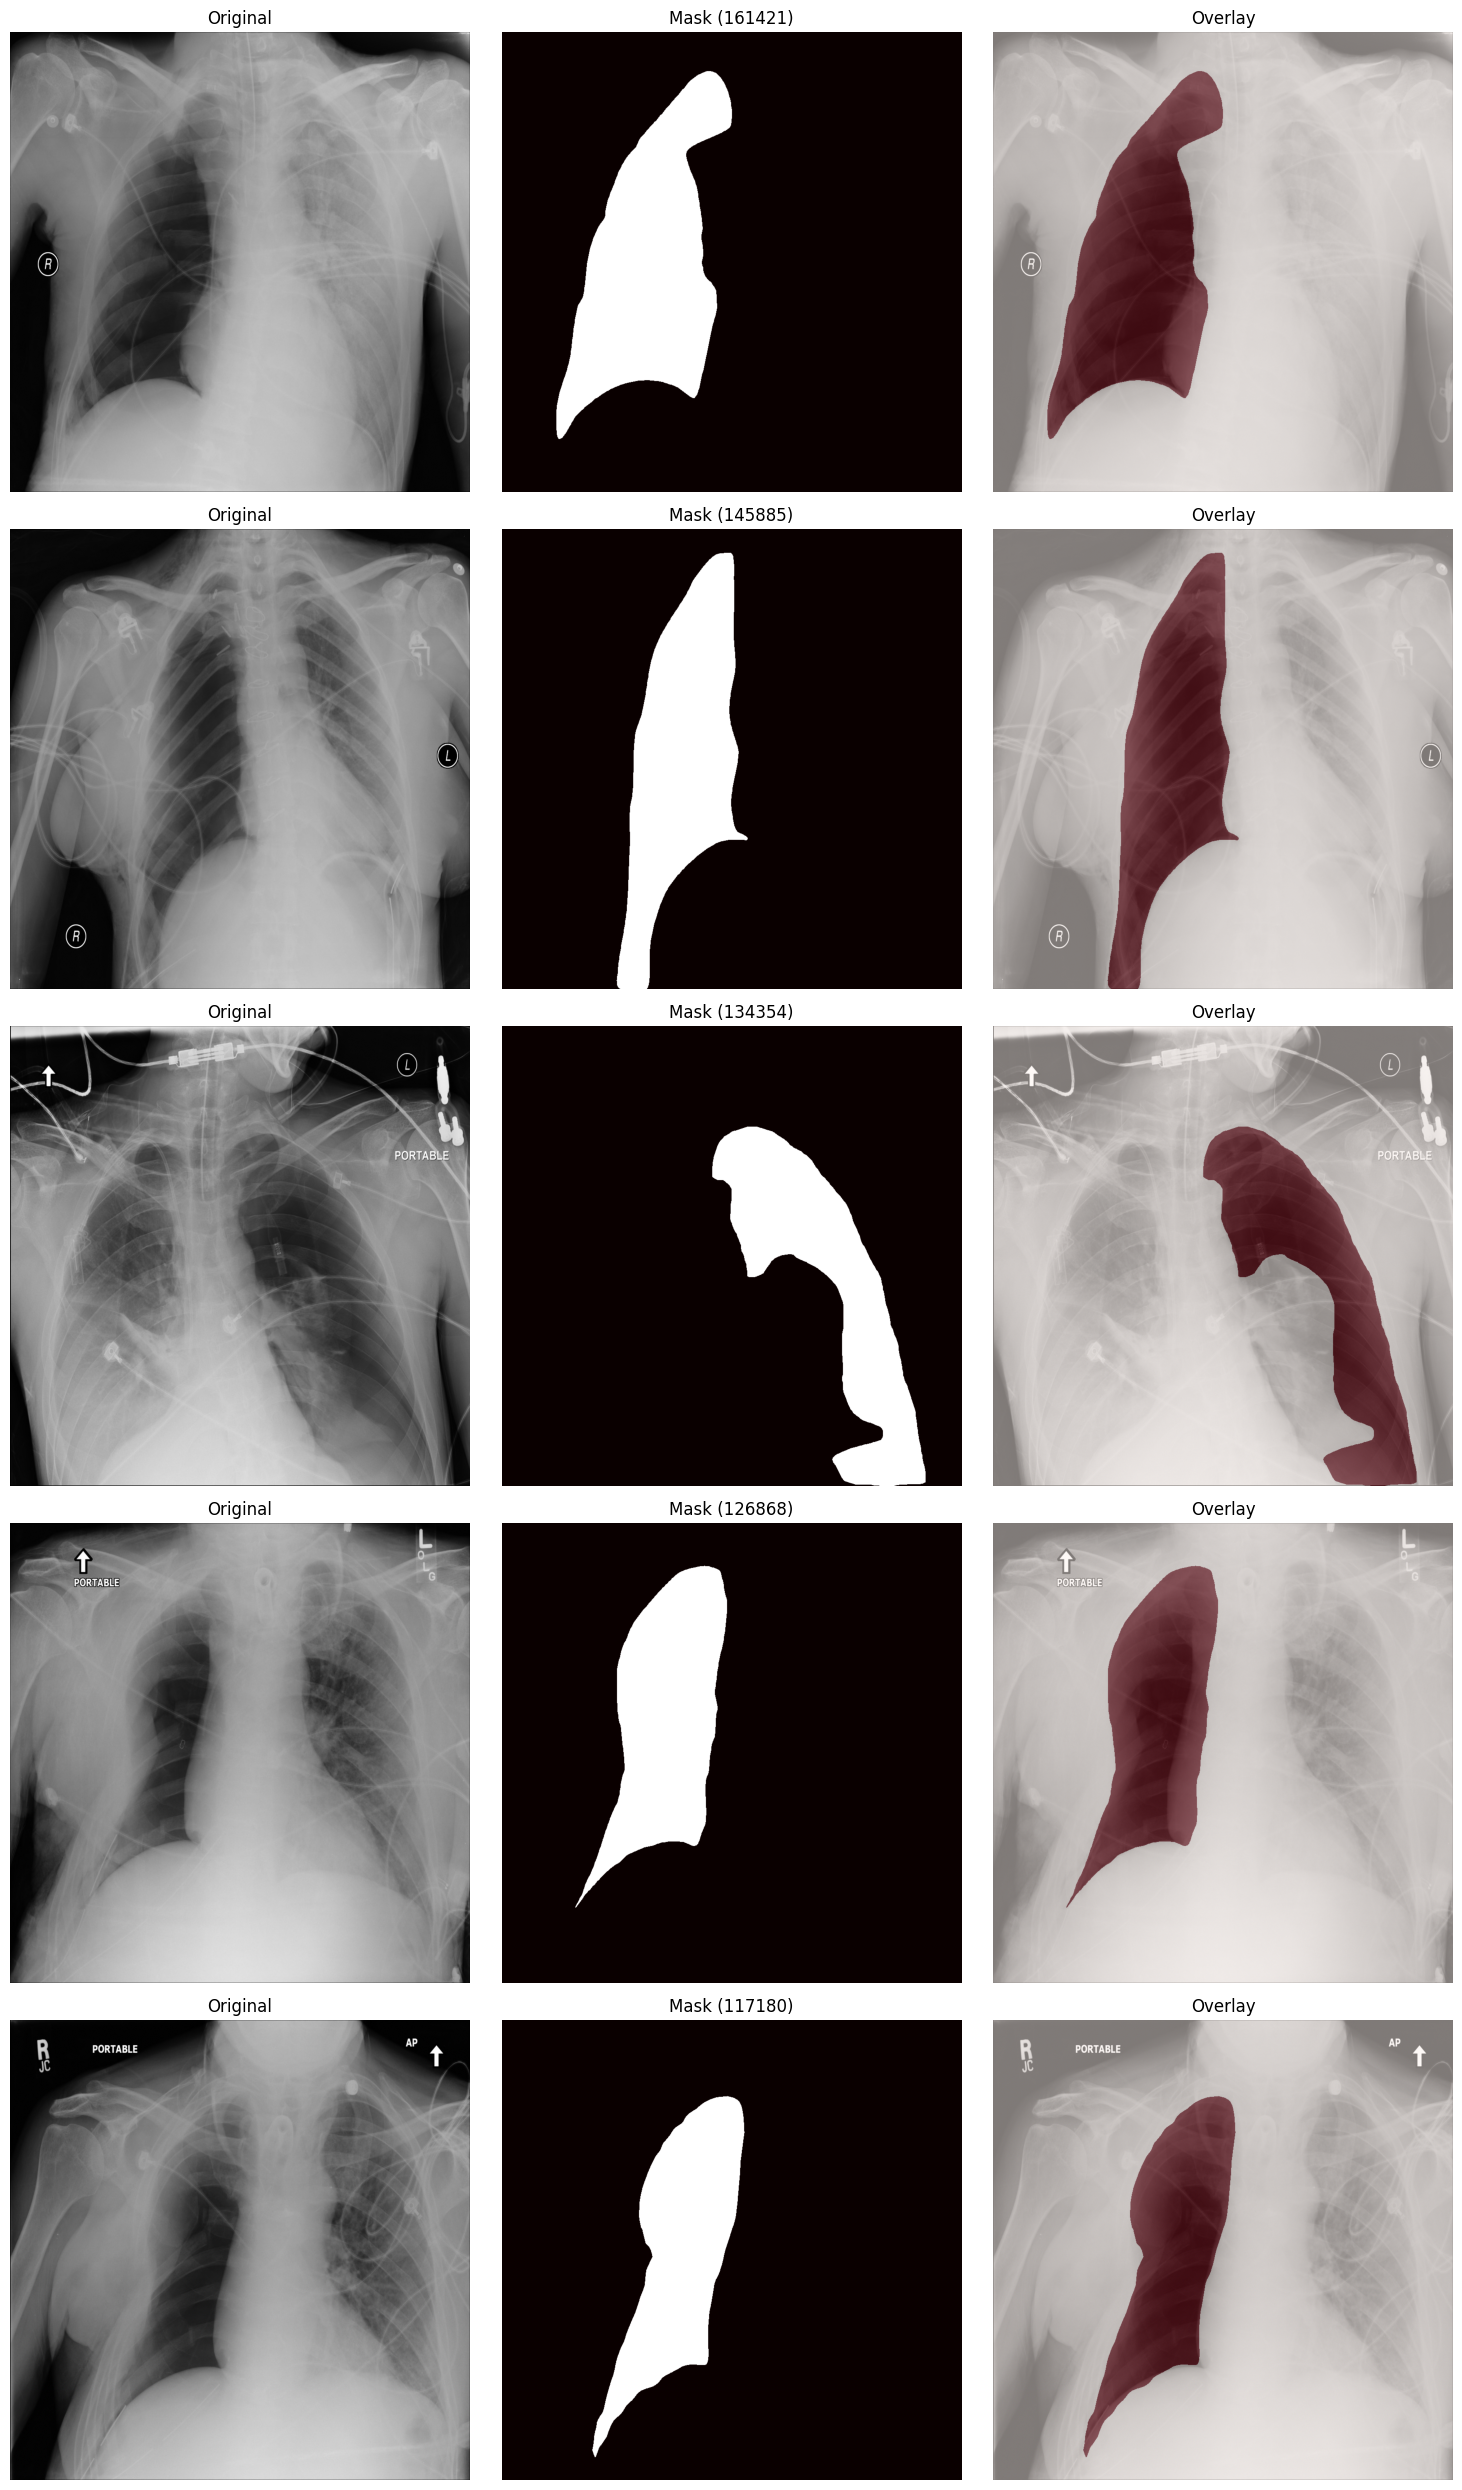

In [ ]:
large_ids = mask_df.head(5)['ImageId'].values

fig, axes = plt.subplots(5, 3, figsize=(15, 25))
for idx, img_id in enumerate(large_ids):
    file_path = list(train_dicom_path.rglob(f'{img_id}.dcm'))[0]
    dcm = pydicom.dcmread(file_path)
    img = dcm.pixel_array
    
    rle = train_rle[train_rle['ImageId'] == img_id][' EncodedPixels'].values[0]
    mask = rle_decode(rle, 1024, 1024)
    
    axes[idx, 0].imshow(img, cmap='gray')
    axes[idx, 0].set_title('Original')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(mask, cmap='hot')
    axes[idx, 1].set_title(f'Mask ({mask.sum()})')
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(img, cmap='gray')
    axes[idx, 2].imshow(mask, cmap='Reds', alpha=0.5)
    axes[idx, 2].set_title('Overlay')
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()

Pneumothorax 있음: 3286 (28.37%)
Pneumothorax 없음: 8296 (71.63%)


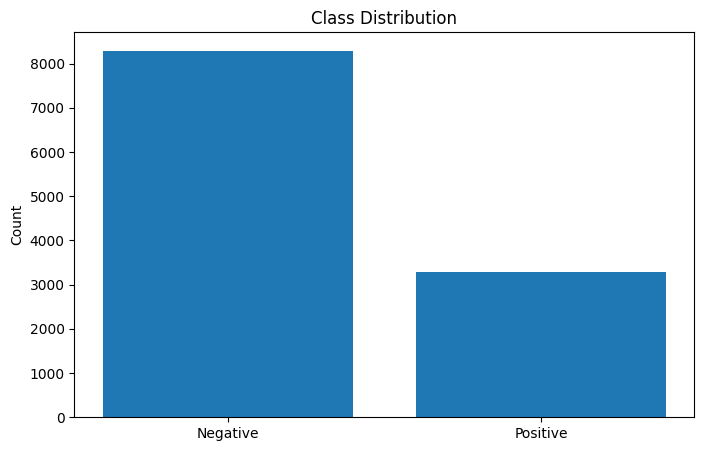


=== 기흉 위치 분포 분석 시작 ===

총 3286개의 양성 케이스 분석 중...
분석 완료: 3286개 샘플


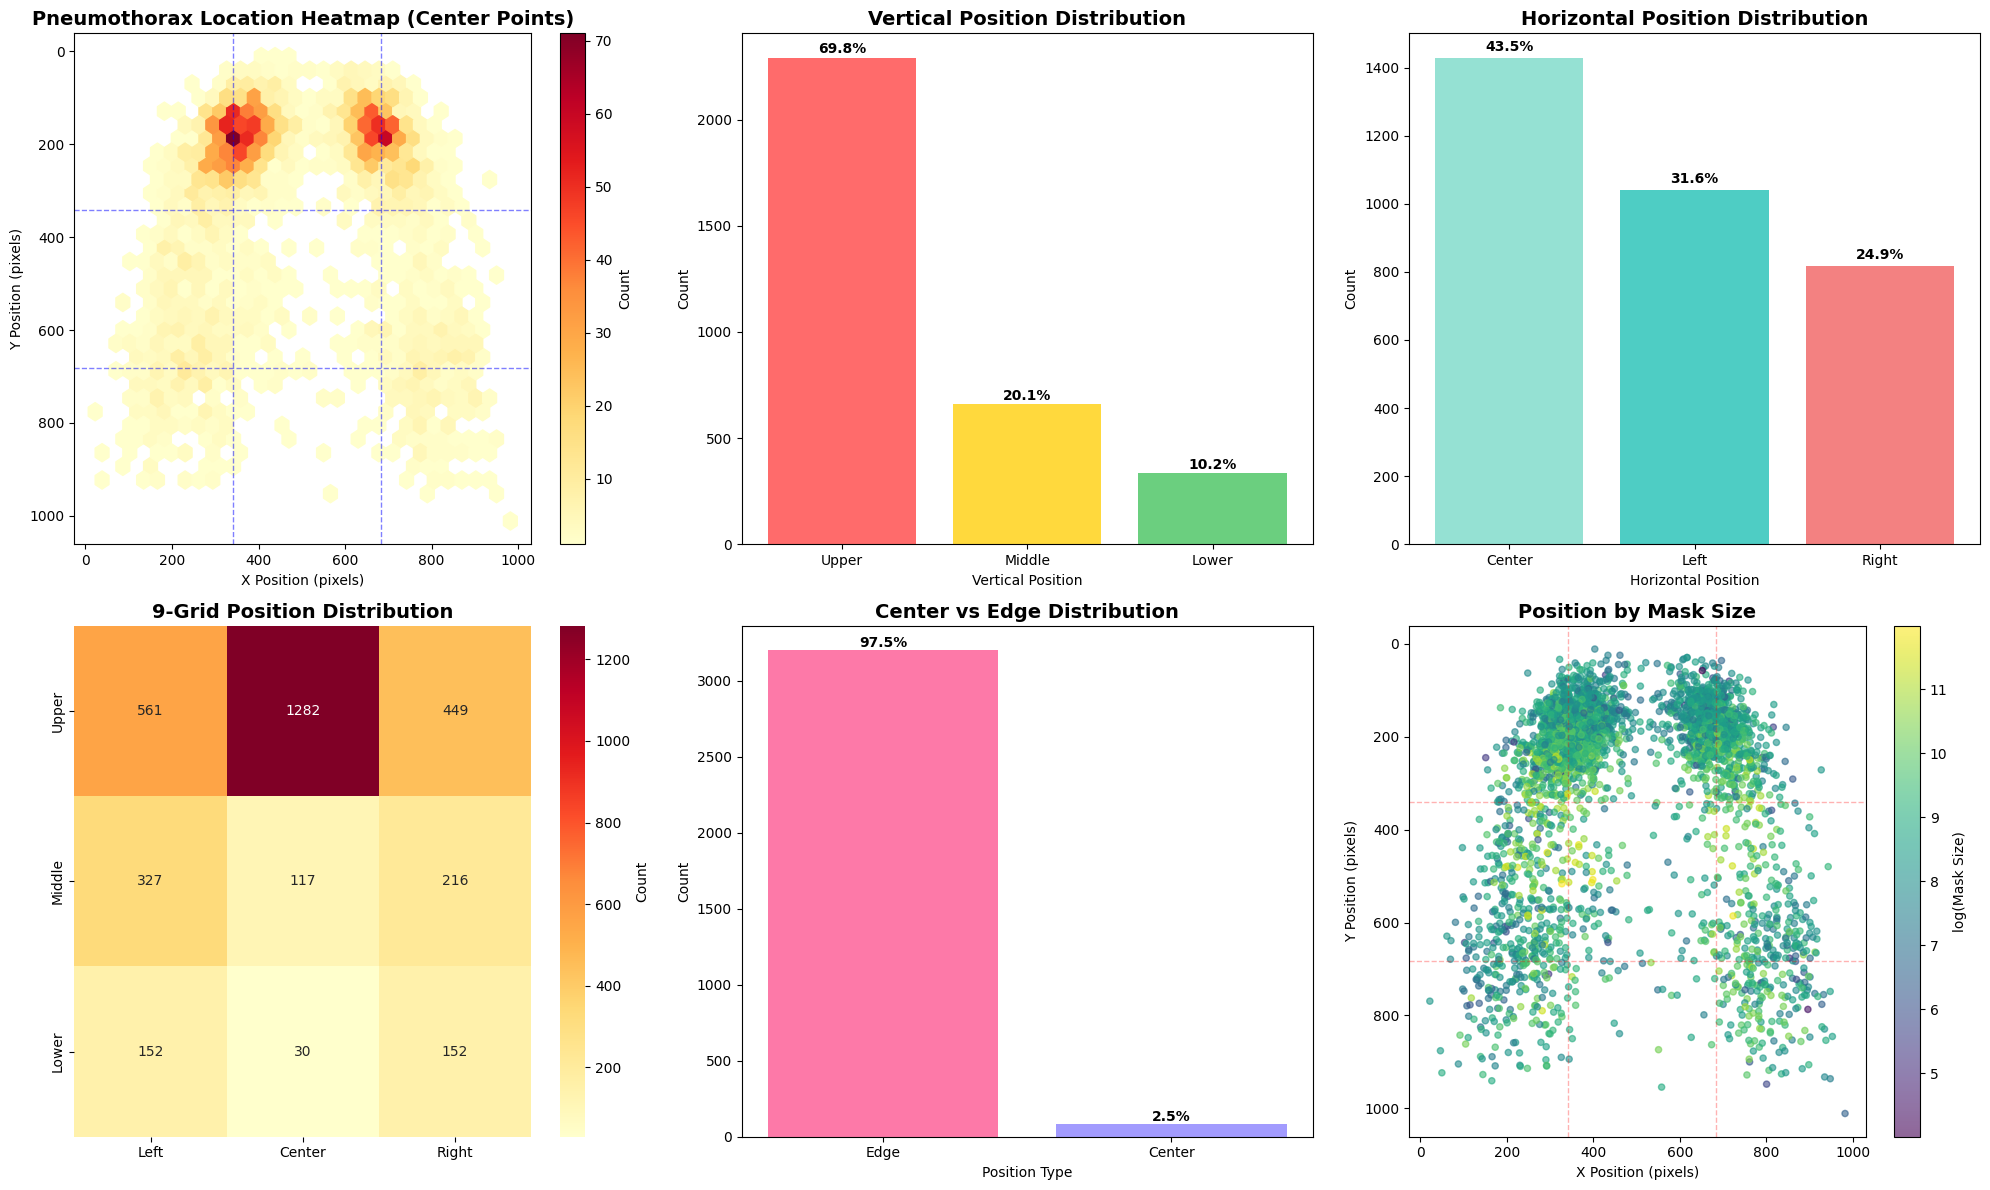


=== 위치별 분포 통계 ===

1. 수직 위치 분포:
   Upper   : 2292 (69.75%)
   Middle  :  660 (20.09%)
   Lower   :  334 (10.16%)

2. 수평 위치 분포:
   Left    : 1040 (31.65%)
   Center  : 1429 (43.49%)
   Right   :  817 (24.86%)

3. 9개 그리드 분포:
   Upper-Left     :  561 (17.07%)
   Upper-Center   : 1282 (39.01%)
   Upper-Right    :  449 (13.66%)
   Middle-Left    :  327 ( 9.95%)
   Middle-Center  :  117 ( 3.56%)
   Middle-Right   :  216 ( 6.57%)
   Lower-Left     :  152 ( 4.63%)
   Lower-Center   :   30 ( 0.91%)
   Lower-Right    :  152 ( 4.63%)

4. Center vs Edge 분포:
   Center  :   83 ( 2.53%)
   Edge    : 3203 (97.47%)

=== 크기별 위치 분포 ===

크기별 수직 위치 분포:
Vertical            Lower  Middle  Upper
Size                                    
Large (5-10%)        6.15   67.69  26.15
Medium (1-5%)       12.22   19.25  68.53
Small (0.1-1%)       8.98   18.44  72.57
Very Large (>10%)    0.00   83.33  16.67
Very Small (<0.1%)  15.23   25.17  59.60

크기별 Center vs Edge 분포:
CenterEdge          Center   Edge
Size          

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pydicom
from pathlib import Path
import cv2

train_rle = pd.read_csv('pneumothorax_data/train-rle.csv')
train_dicom_path = Path('pneumothorax_data/dicom-images-train')

train_rle['has_pneumothorax'] = (train_rle[' EncodedPixels'] != ' -1')

positive = train_rle['has_pneumothorax'].sum()
negative = len(train_rle) - positive

print(f"Pneumothorax 있음: {positive} ({positive/len(train_rle)*100:.2f}%)")
print(f"Pneumothorax 없음: {negative} ({negative/len(train_rle)*100:.2f}%)")

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(['Negative', 'Positive'], [negative, positive])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

def rle_decode(rle, width, height):
    if pd.isna(rle) or str(rle).strip() == '-1':
        return np.zeros((height, width), dtype=np.uint8)
    
    array = np.asarray([int(x) for x in str(rle).strip().split()]) #RLE 문자열 -> int 리스트
    starts = array[0::2] #짝수 인덱스값 : mask 픽셀 사이 간격
    lengths = array[1::2] #홀수 인덱스 : mask 길이
    
    current_position = 0
    mask = np.zeros(width * height, dtype=np.uint8)
    
    for start, length in zip(starts, lengths):
        current_position += start
        mask[current_position:current_position+length] = 1
        current_position += length
    
    return mask.reshape(width, height).T

# ==================== 위치 분포 EDA ====================

print("\n=== 기흉 위치 분포 분석 시작 ===\n")

# 마스크 중심점 계산 함수
def get_mask_center(mask):
    y_indices, x_indices = np.where(mask > 0)
    if len(y_indices) == 0:
        return None, None
    center_y = np.mean(y_indices)
    center_x = np.mean(x_indices)
    return center_y, center_x

# 위치 분류 함수
def classify_position(center_y, center_x, img_h, img_w):
    if center_y < img_h / 3:
        vertical = "Upper"
    elif center_y < 2 * img_h / 3:
        vertical = "Middle"
    else:
        vertical = "Lower"
    
    if center_x < img_w / 3:
        horizontal = "Left"
    elif center_x < 2 * img_w / 3:
        horizontal = "Center"
    else:
        horizontal = "Right"
    
    return vertical, horizontal

def classify_center_edge(center_y, center_x, img_h, img_w, threshold=0.3):

    norm_dist_y = abs(center_y - img_h/2) / (img_h/2)
    norm_dist_x = abs(center_x - img_w/2) / (img_w/2)
    max_dist = max(norm_dist_y, norm_dist_x)
    
    if max_dist < threshold:
        return "Center"
    else:
        return "Edge"

positive_cases = train_rle[train_rle['has_pneumothorax']].copy()

centers = []
sizes = []
positions = []
center_edge = []
vertical_positions = []
horizontal_positions = []

for idx, row in positive_cases.iterrows():
    image_id = row['ImageId']
    rle = row[' EncodedPixels']
    
    mask = rle_decode(rle, 1024, 1024)
    
    if mask.sum() == 0:
        continue
    
    center_y, center_x = get_mask_center(mask)
    if center_y is None:
        continue
    
    vertical, horizontal = classify_position(center_y, center_x, 1024, 1024)
    ce_class = classify_center_edge(center_y, center_x, 1024, 1024)
    
    centers.append((center_x, center_y))
    sizes.append(mask.sum())
    positions.append(f"{vertical}-{horizontal}")
    center_edge.append(ce_class)
    vertical_positions.append(vertical)
    horizontal_positions.append(horizontal)

fig = plt.figure(figsize=(20, 12))

ax1 = plt.subplot(2, 3, 1)
x_coords = [c[0] for c in centers]
y_coords = [c[1] for c in centers]
h = ax1.hexbin(x_coords, y_coords, gridsize=30, cmap='YlOrRd', mincnt=1)
plt.colorbar(h, ax=ax1, label='Count')
ax1.set_xlabel('X Position (pixels)')
ax1.set_ylabel('Y Position (pixels)')
ax1.set_title('Pneumothorax Location Heatmap (Center Points)', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.axhline(y=1024/3, color='blue', linestyle='--', alpha=0.5, linewidth=1)
ax1.axhline(y=2*1024/3, color='blue', linestyle='--', alpha=0.5, linewidth=1)
ax1.axvline(x=1024/3, color='blue', linestyle='--', alpha=0.5, linewidth=1)
ax1.axvline(x=2*1024/3, color='blue', linestyle='--', alpha=0.5, linewidth=1)

ax2 = plt.subplot(2, 3, 2)
vertical_counts = pd.Series(vertical_positions).value_counts()
colors = {'Upper': '#ff6b6b', 'Middle': '#ffd93d', 'Lower': '#6bcf7f'}
bars = ax2.bar(vertical_counts.index, vertical_counts.values, 
               color=[colors[x] for x in vertical_counts.index])
ax2.set_xlabel('Vertical Position')
ax2.set_ylabel('Count')
ax2.set_title('Vertical Position Distribution', fontsize=14, fontweight='bold')

for i, (pos, count) in enumerate(vertical_counts.items()):
    percentage = count / len(vertical_positions) * 100
    ax2.text(i, count + 20, f'{percentage:.1f}%', ha='center', fontweight='bold')

ax3 = plt.subplot(2, 3, 3)
horizontal_counts = pd.Series(horizontal_positions).value_counts()
colors_h = {'Left': '#4ecdc4', 'Center': '#95e1d3', 'Right': '#f38181'}
bars = ax3.bar(horizontal_counts.index, horizontal_counts.values,
               color=[colors_h[x] for x in horizontal_counts.index])
ax3.set_xlabel('Horizontal Position')
ax3.set_ylabel('Count')
ax3.set_title('Horizontal Position Distribution', fontsize=14, fontweight='bold')

for i, (pos, count) in enumerate(horizontal_counts.items()):
    percentage = count / len(horizontal_positions) * 100
    ax3.text(i, count + 20, f'{percentage:.1f}%', ha='center', fontweight='bold')

ax4 = plt.subplot(2, 3, 4)
position_counts = pd.Series(positions).value_counts()
grid_data = np.zeros((3, 3))
position_mapping = {
    'Upper-Left': (0, 0), 'Upper-Center': (0, 1), 'Upper-Right': (0, 2),
    'Middle-Left': (1, 0), 'Middle-Center': (1, 1), 'Middle-Right': (1, 2),
    'Lower-Left': (2, 0), 'Lower-Center': (2, 1), 'Lower-Right': (2, 2)
}
for pos, count in position_counts.items():
    i, j = position_mapping[pos]
    grid_data[i, j] = count

sns.heatmap(grid_data, annot=True, fmt='.0f', cmap='YlOrRd', 
            xticklabels=['Left', 'Center', 'Right'],
            yticklabels=['Upper', 'Middle', 'Lower'],
            cbar_kws={'label': 'Count'}, ax=ax4)
ax4.set_title('9-Grid Position Distribution', fontsize=14, fontweight='bold')

#Center vs Edge 분포
ax5 = plt.subplot(2, 3, 5)
ce_counts = pd.Series(center_edge).value_counts()
colors_ce = {'Center': '#a29bfe', 'Edge': '#fd79a8'}
bars = ax5.bar(ce_counts.index, ce_counts.values,
               color=[colors_ce[x] for x in ce_counts.index])
ax5.set_xlabel('Position Type')
ax5.set_ylabel('Count')
ax5.set_title('Center vs Edge Distribution', fontsize=14, fontweight='bold')

for i, (pos, count) in enumerate(ce_counts.items()):
    percentage = count / len(center_edge) * 100
    ax5.text(i, count + 20, f'{percentage:.1f}%', ha='center', fontweight='bold')

ax6 = plt.subplot(2, 3, 6)
size_array = np.array(sizes)
# 크기별 색상 구분
colors_scatter = plt.cm.viridis(np.log(size_array) / np.log(size_array.max()))
scatter = ax6.scatter(x_coords, y_coords, c=np.log(size_array), 
                      cmap='viridis', alpha=0.6, s=20)
plt.colorbar(scatter, ax=ax6, label='log(Mask Size)')
ax6.set_xlabel('X Position (pixels)')
ax6.set_ylabel('Y Position (pixels)')
ax6.set_title('Position by Mask Size', fontsize=14, fontweight='bold')
ax6.invert_yaxis()
# 그리드 라인 추가
ax6.axhline(y=1024/3, color='red', linestyle='--', alpha=0.3, linewidth=1)
ax6.axhline(y=2*1024/3, color='red', linestyle='--', alpha=0.3, linewidth=1)
ax6.axvline(x=1024/3, color='red', linestyle='--', alpha=0.3, linewidth=1)
ax6.axvline(x=2*1024/3, color='red', linestyle='--', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.savefig('eda_pneumothorax_location_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== 통계 출력 ====================

print("\n=== 위치별 분포 통계 ===\n")

print("1. 수직 위치 분포:")
for pos in ['Upper', 'Middle', 'Lower']:
    count = vertical_positions.count(pos)
    percentage = count / len(vertical_positions) * 100
    print(f"   {pos:8s}: {count:4d} ({percentage:5.2f}%)")

print("\n2. 수평 위치 분포:")
for pos in ['Left', 'Center', 'Right']:
    count = horizontal_positions.count(pos)
    percentage = count / len(horizontal_positions) * 100
    print(f"   {pos:8s}: {count:4d} ({percentage:5.2f}%)")

print("\n3. 9개 그리드 분포:")
for pos in ['Upper-Left', 'Upper-Center', 'Upper-Right',
            'Middle-Left', 'Middle-Center', 'Middle-Right',
            'Lower-Left', 'Lower-Center', 'Lower-Right']:
    count = positions.count(pos)
    percentage = count / len(positions) * 100
    print(f"   {pos:15s}: {count:4d} ({percentage:5.2f}%)")

print("\n4. Center vs Edge 분포:")
for pos in ['Center', 'Edge']:
    count = center_edge.count(pos)
    percentage = count / len(center_edge) * 100
    print(f"   {pos:8s}: {count:4d} ({percentage:5.2f}%)")

# ==================== 크기별 위치 분석 ====================

print("\n=== 크기별 위치 분포 ===\n")

# 크기 범주 정의
size_categories = []
for size in sizes:
    percentage = (size / (1024 * 1024)) * 100
    if percentage < 0.1:
        size_categories.append('Very Small (<0.1%)')
    elif percentage < 1:
        size_categories.append('Small (0.1-1%)')
    elif percentage < 5:
        size_categories.append('Medium (1-5%)')
    elif percentage < 10:
        size_categories.append('Large (5-10%)')
    else:
        size_categories.append('Very Large (>10%)')

# 크기별 수직 위치 분포
size_vertical_df = pd.DataFrame({
    'Size': size_categories,
    'Vertical': vertical_positions
})

print("크기별 수직 위치 분포:")
size_vertical_crosstab = pd.crosstab(size_vertical_df['Size'], 
                                      size_vertical_df['Vertical'], 
                                      normalize='index') * 100
print(size_vertical_crosstab.round(2))

# 크기별 Center vs Edge 분포
size_ce_df = pd.DataFrame({
    'Size': size_categories,
    'CenterEdge': center_edge
})

print("\n크기별 Center vs Edge 분포:")
size_ce_crosstab = pd.crosstab(size_ce_df['Size'], 
                                size_ce_df['CenterEdge'], 
                                normalize='index') * 100
print(size_ce_crosstab.round(2))

print("\n=== EDA 완료 ===")

Top 10 small masks:
                                                ImageId  mask_size
2810  1.2.276.0.7230010.3.1.4.8323329.338.1517875162...         55
879   1.2.276.0.7230010.3.1.4.8323329.32421.15178751...         80
902   1.2.276.0.7230010.3.1.4.8323329.32462.15178751...        123
380   1.2.276.0.7230010.3.1.4.8323329.12376.15178752...        201
1565  1.2.276.0.7230010.3.1.4.8323329.31716.15178751...        210
329   1.2.276.0.7230010.3.1.4.8323329.12786.15178752...        212
1527  1.2.276.0.7230010.3.1.4.8323329.31952.15178751...        219
1172  1.2.276.0.7230010.3.1.4.8323329.31964.15178751...        220
1043  1.2.276.0.7230010.3.1.4.8323329.4343.151787518...        222
338   1.2.276.0.7230010.3.1.4.8323329.5396.151787518...        252


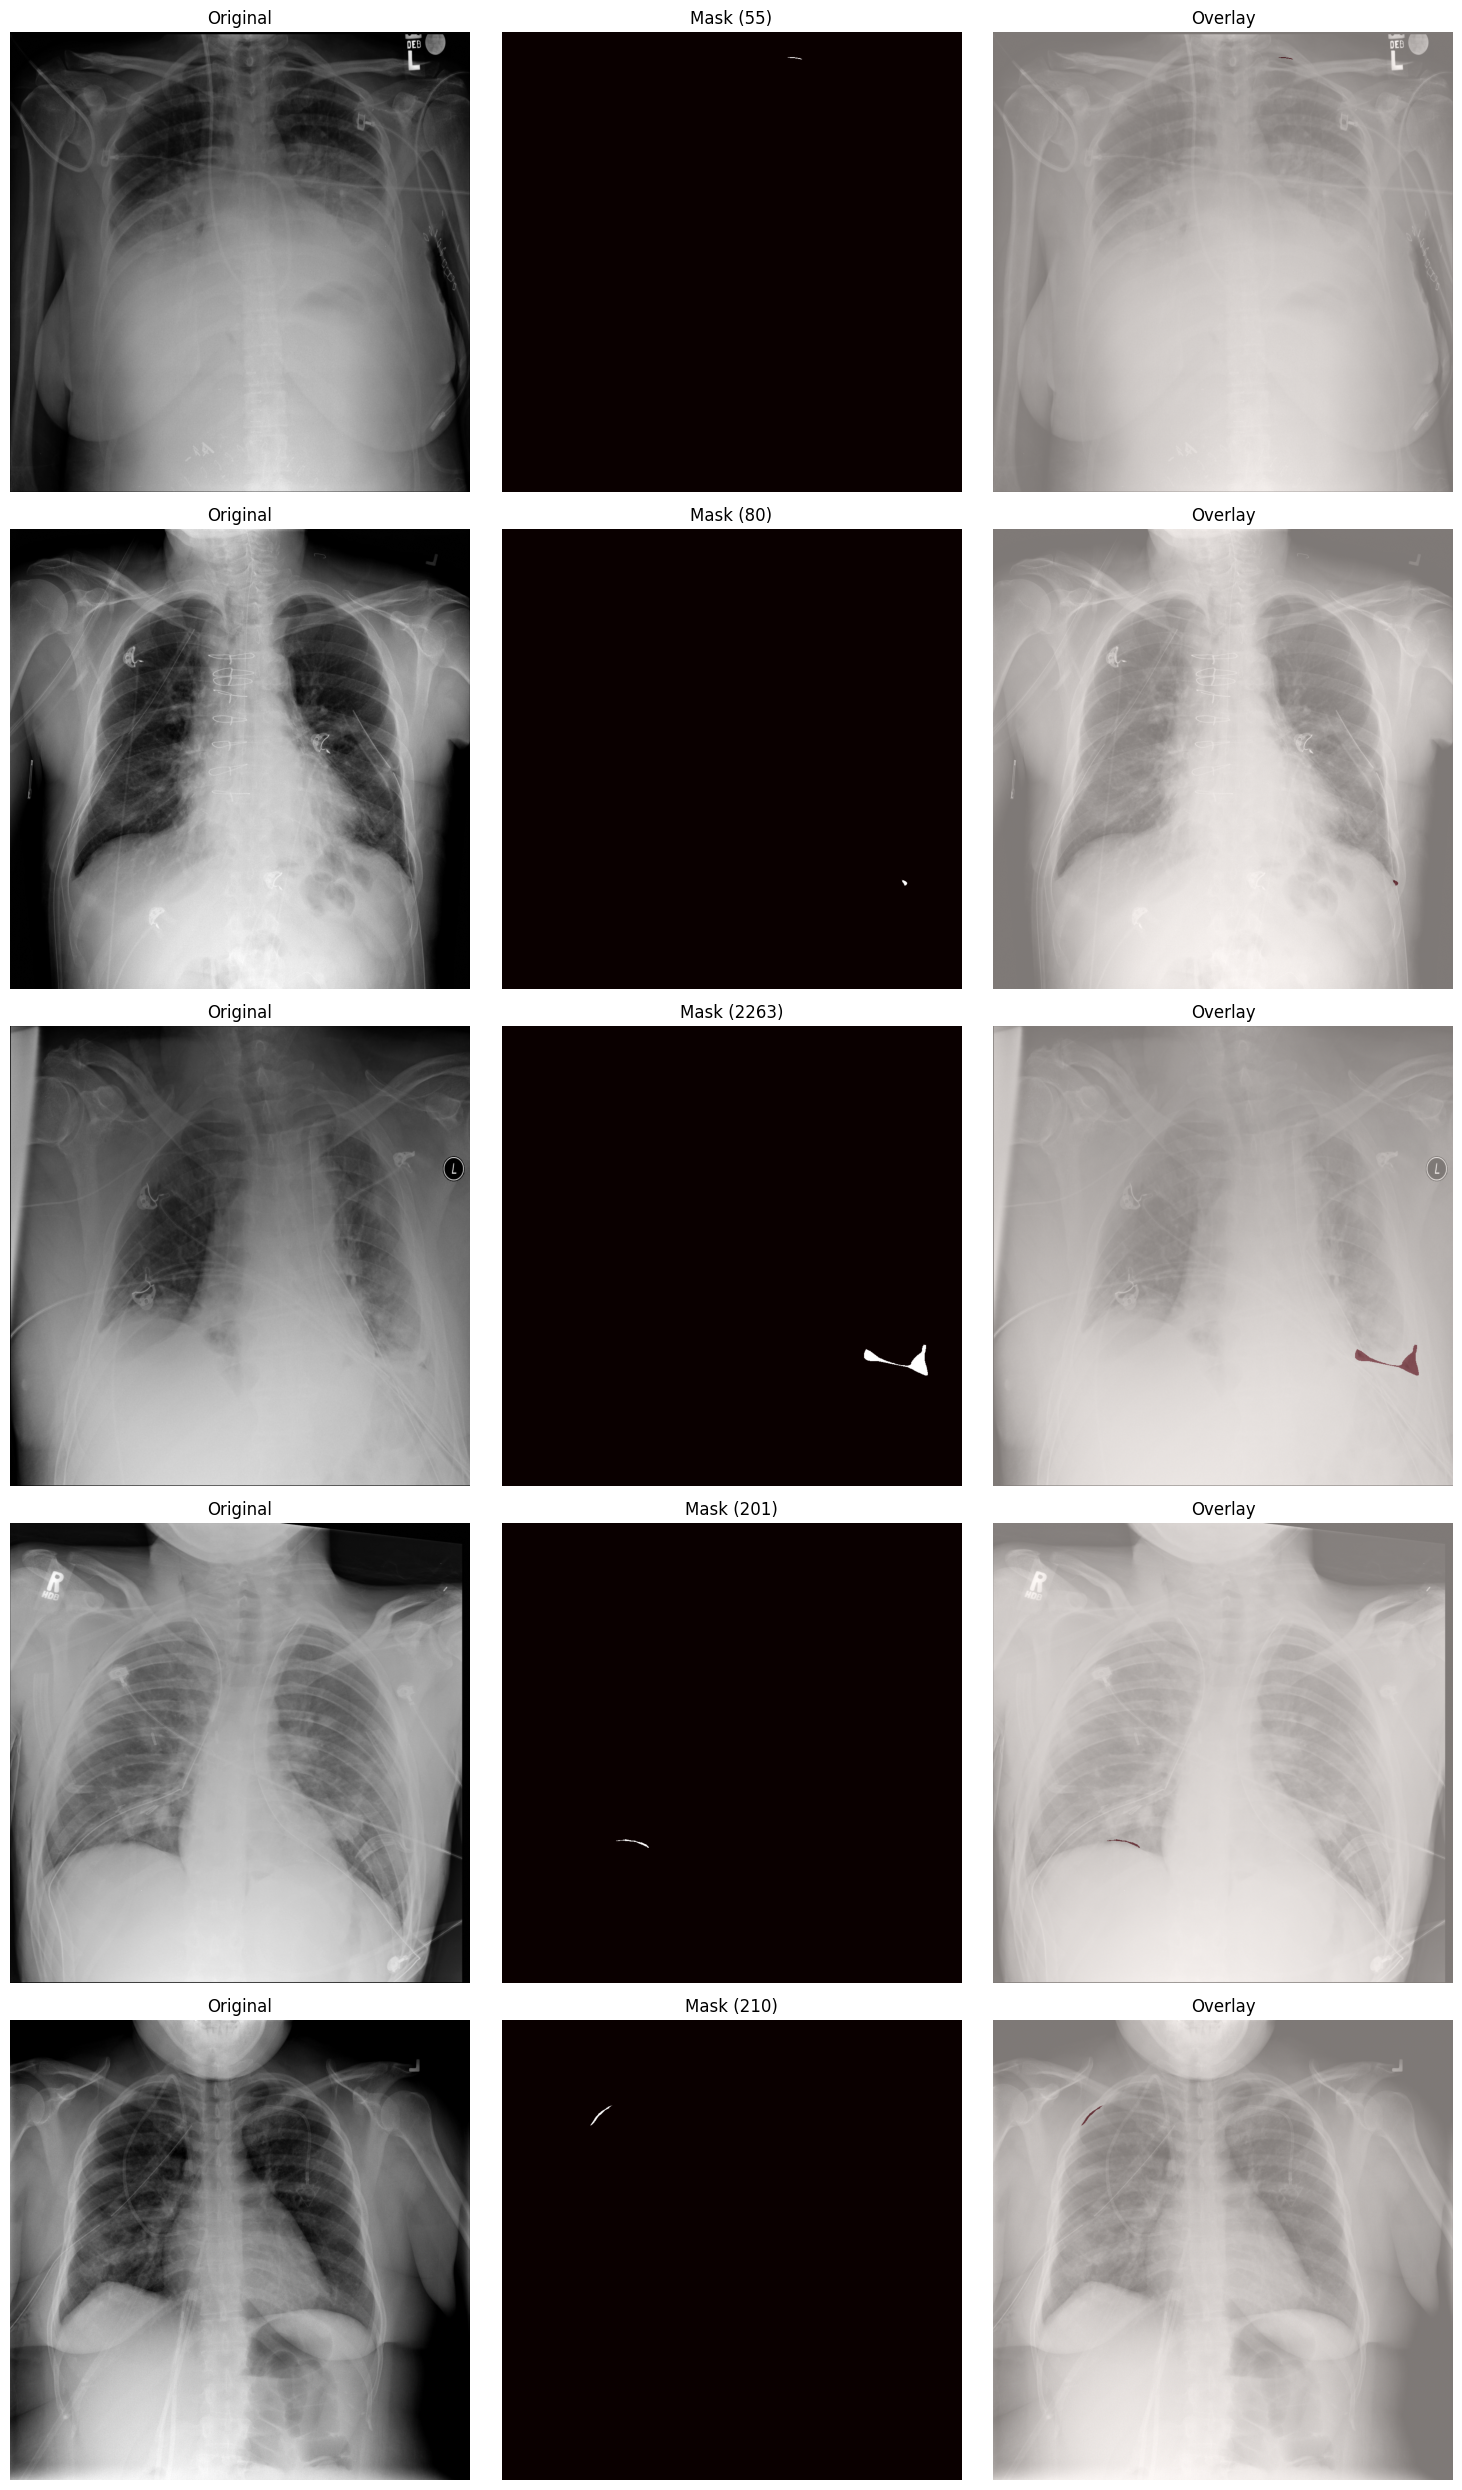

In [ ]:
mask_sizes = []
for idx, row in train_rle[train_rle['has_pneumothorax']].iterrows():
    rle = row[' EncodedPixels']
    s = rle.split()
    lengths = np.asarray(s[1::2], dtype=int)
    total_size = lengths.sum()
    mask_sizes.append({'ImageId': row['ImageId'], 'mask_size': total_size})

mask_df_min = pd.DataFrame(mask_sizes).sort_values('mask_size', ascending=True)
print("Top 10 small masks:")
print(mask_df_min.head(10))

small_ids = mask_df_min.head(5)['ImageId'].values

fig, axes = plt.subplots(5, 3, figsize=(15, 25))
for idx, img_id in enumerate(small_ids):
    file_path = list(train_dicom_path.rglob(f'{img_id}.dcm'))[0]
    dcm = pydicom.dcmread(file_path)
    img = dcm.pixel_array
    
    rle = train_rle[train_rle['ImageId'] == img_id][' EncodedPixels'].values[0]
    mask = rle_decode(rle, 1024, 1024)
    
    axes[idx, 0].imshow(img, cmap='gray')
    axes[idx, 0].set_title('Original')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(mask, cmap='hot')
    axes[idx, 1].set_title(f'Mask ({mask.sum()})')
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(img, cmap='gray')
    axes[idx, 2].imshow(mask, cmap='Reds', alpha=0.5)
    axes[idx, 2].set_title('Overlay')
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()

### mask 크기 분포


Mask area statistics:
Mean: 10836 pixels (1.03%)
Median: 6250 pixels
Min: 55 pixels
Max: 161421 pixels


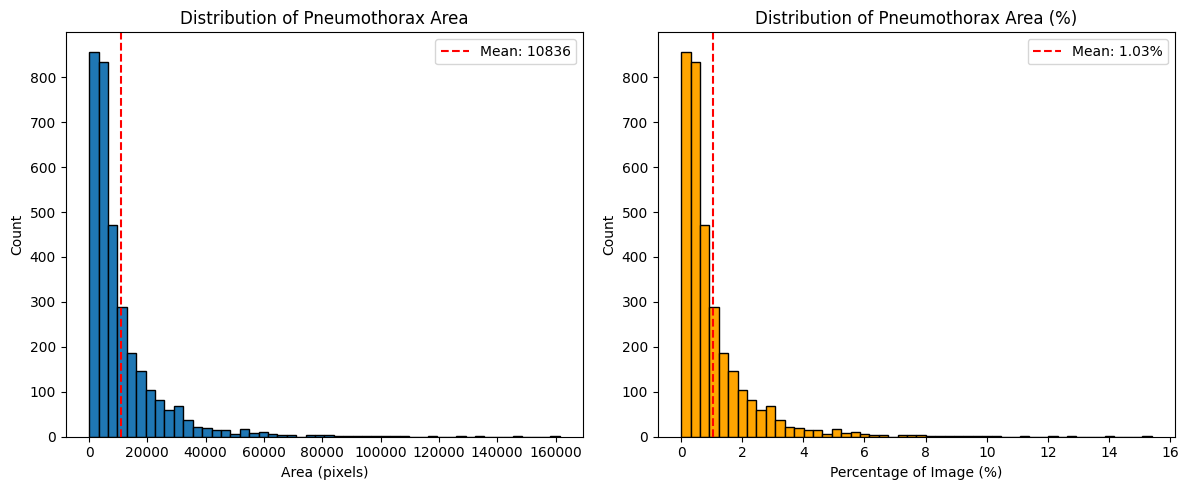

In [ ]:
mask_areas = []
for _, row in train_rle[train_rle['has_pneumothorax']].iterrows():
    mask = rle_decode(row[' EncodedPixels'], 1024, 1024)
    mask_areas.append(mask.sum())

mask_areas = np.array(mask_areas)

print(f"\nMask area statistics:")
print(f"Mean: {mask_areas.mean():.0f} pixels ({mask_areas.mean()/(1024*1024)*100:.2f}%)")
print(f"Median: {np.median(mask_areas):.0f} pixels")
print(f"Min: {mask_areas.min():.0f} pixels")
print(f"Max: {mask_areas.max():.0f} pixels")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(mask_areas, bins=50, edgecolor='black')
plt.title('Distribution of Pneumothorax Area')
plt.xlabel('Area (pixels)')
plt.ylabel('Count')
plt.axvline(mask_areas.mean(), color='red', linestyle='--', label=f'Mean: {mask_areas.mean():.0f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(mask_areas/(1024*1024)*100, bins=50, edgecolor='black', color='orange')
plt.title('Distribution of Pneumothorax Area (%)')
plt.xlabel('Percentage of Image (%)')
plt.ylabel('Count')
plt.axvline(mask_areas.mean()/(1024*1024)*100, color='red', linestyle='--', 
            label=f'Mean: {mask_areas.mean()/(1024*1024)*100:.2f}%')
plt.legend()

plt.tight_layout()
plt.show()

- 대부분 pneumothorax영역이 작다. 평균 : 10836 픽셀
- 클래스 불균형 : 양성 샘플 자체가 매우 적음(22%), 양성 샘플도 영역이 작은게 대부분
- False Negative가 높을 것으로 예상됨

### 픽셀 강도 분포
- 이미지 간 밝기 편차가 꽤 큼 (오른쪽 Boxplot)
- 매우 어두운 픽셀(배경) 비율이 높은 편

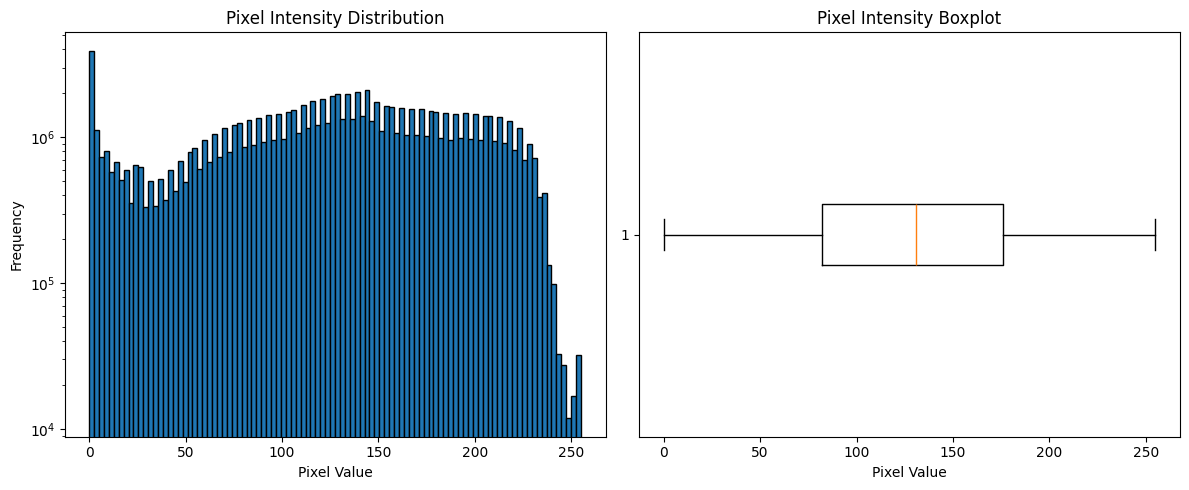

In [ ]:
# 7. 이미지 픽셀 값 분포
sample_images = []
for file_path in list(train_dicom_path.rglob('*.dcm'))[:100]:
    dcm = pydicom.dcmread(file_path)
    sample_images.append(dcm.pixel_array.flatten())

all_pixels = np.concatenate(sample_images)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(all_pixels, bins=100, edgecolor='black')
plt.title('Pixel Intensity Distribution')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.boxplot(all_pixels, vert=False)
plt.title('Pixel Intensity Boxplot')
plt.xlabel('Pixel Value')

plt.tight_layout()
plt.show()

C:\Users\sua10\AppData\Local\Temp\ipykernel_42024\1507944949.py:25: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(


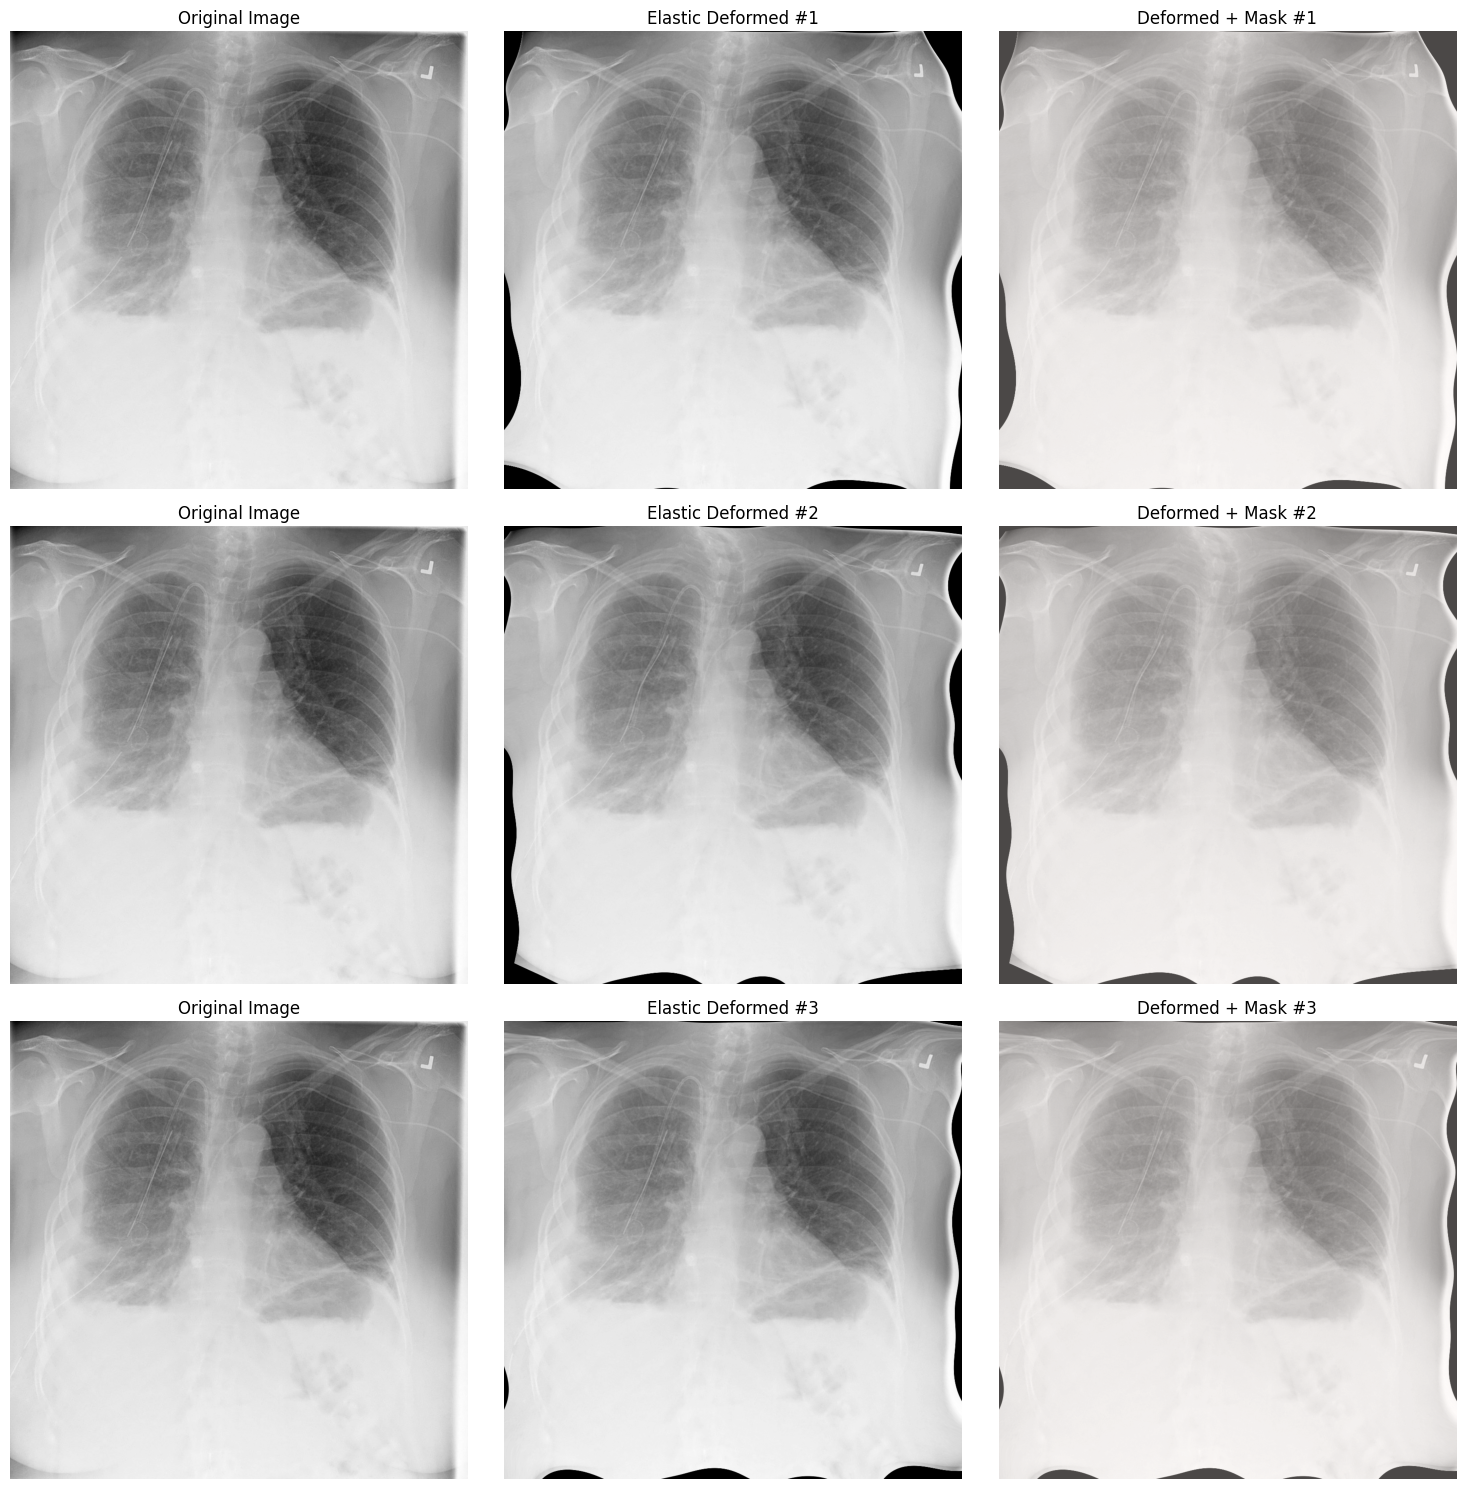

In [7]:
import albumentations as A
import matplotlib.pyplot as plt

# 샘플 이미지와 마스크 로드
sample_id = train_rle[train_rle[' EncodedPixels'] != '-1'].iloc[0]['ImageId']
sample_dcm_path = list(train_dicom_path.rglob(f'{sample_id}*'))[0]
dcm = pydicom.dcmread(sample_dcm_path)
image = dcm.pixel_array

# 마스크 생성 (RLE 디코딩)
def rle_decode(mask_rle, shape=(1024, 1024)):
    s = mask_rle.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape).T

mask = rle_decode(train_rle[train_rle['ImageId'] == sample_id].iloc[0][' EncodedPixels'])

# Elastic Transform 정의
elastic_transform = A.Compose([
    A.ElasticTransform(
        alpha=3500,
        sigma=50,
        alpha_affine=24,
        p=1.0  # 항상 적용되도록 설정
    )
])

# 3개의 다른 elastic deformation 생성 및 시각화
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i in range(3):
    # Elastic transformation 적용
    transformed = elastic_transform(image=image, mask=mask)
    transformed_image = transformed['image']
    transformed_mask = transformed['mask']
    
    # 원본 이미지
    axes[i, 0].imshow(image, cmap='gray')
    axes[i, 0].set_title(f'Original Image', fontsize=12)
    axes[i, 0].axis('off')
    
    # 변형된 이미지
    axes[i, 1].imshow(transformed_image, cmap='gray')
    axes[i, 1].set_title(f'Elastic Deformed #{i+1}', fontsize=12)
    axes[i, 1].axis('off')
    
    # 오버레이 (이미지 + 마스크)
    axes[i, 2].imshow(transformed_image, cmap='gray')
    axes[i, 2].imshow(transformed_mask, cmap='Reds', alpha=0.3)
    axes[i, 2].set_title(f'Deformed + Mask #{i+1}', fontsize=12)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()